In [1]:
# se importan librerias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# se carga el dataset
df = pd.read_csv('../data/customer_acquisition_data.csv')
df.head()

,customer_id,channel,cost,conversion_rate,revenue
0,1,referral,8.320327,0.123145,4199
1,2,paid advertising,30.450327,0.016341,3410
2,3,email marketing,5.246263,0.043822,3164
3,4,social media,9.546326,0.167592,1520
4,5,referral,8.320327,0.123145,2419


In [3]:
# se crea la columna net_value
df['net_value'] = df['revenue'] - df['cost'].round(3)
df.head()

,customer_id,channel,cost,conversion_rate,revenue,net_value
0,1,referral,8.320327,0.123145,4199,4190.680
1,2,paid advertising,30.450327,0.016341,3410,3379.550
2,3,email marketing,5.246263,0.043822,3164,3158.754
3,4,social media,9.546326,0.167592,1520,1510.454
4,5,referral,8.320327,0.123145,2419,2410.680


In [4]:
df[['revenue','net_value','conversion_rate','cost']].describe()

,revenue,net_value,conversion_rate,cost
count,800.000000,800.000000,800.000000,800.000000
mean,2769.151250,2756.003507,0.086305,13.148052
std,1259.543706,1259.397811,0.059611,9.922337
min,500.000000,479.550000,0.016341,5.246263
25%,1694.000000,1681.101000,0.043822,5.246263
50%,2764.000000,2754.104000,0.043822,8.320327
75%,3824.250000,3809.228000,0.123145,9.546326
max,4998.000000,4985.680000,0.167592,30.450327


## Segmentacion de Clientes
- definir variables para segmentación;
- determinar criterios High/Medium/Low Value
- crear segmentos
- analizar los clientes de cada segmento;
- identificar los clientes más valiosos.

### Definimos variables y criterios de segmentacion

high_value = Net Value > P75
medium_value : P25 > Net_Value <= P75
low_value : Net_Value <= P25


In [5]:
# Definimos la función para segmentar los clientes

def segment_customer(df):

    # Net value percentiles
    net_value_p25 = df["net_value"].quantile(0.25)
    net_value_p75 = df["net_value"].quantile(0.75)

    # High Value
    high_value = (
        df["net_value"] > net_value_p75
    )

    # Medium Value
    medium_value = (
        (df["net_value"] > net_value_p25) &
        (df["net_value"] <= net_value_p75)
    )

    # Low Value
    low_value = (
        df["net_value"] <= net_value_p25
    )

    # Assign segments
    df["customer_segment"] = np.select(
        [high_value, medium_value, low_value],
        ["High Value", "Medium Value", "Low Value"],
        default="Other"
    )

    return df

In [6]:
df_segmented = segment_customer(df)
df_segmented.head()

,customer_id,channel,cost,conversion_rate,revenue,net_value,customer_segment
0,1,referral,8.320327,0.123145,4199,4190.680,High Value
1,2,paid advertising,30.450327,0.016341,3410,3379.550,Medium Value
2,3,email marketing,5.246263,0.043822,3164,3158.754,Medium Value
3,4,social media,9.546326,0.167592,1520,1510.454,Low Value
4,5,referral,8.320327,0.123145,2419,2410.680,Medium Value


In [7]:
df_segmented['customer_segment'].value_counts()

customer_segment
Medium Value    400
High Value      200
Low Value       200
Name: count, dtype: int64

In [8]:
df_segmented['customer_segment'].value_counts(normalize=True)

customer_segment
Medium Value    0.50
High Value      0.25
Low Value       0.25
Name: proportion, dtype: float64

### Metodología de segmentación

Se implementó una metodología simple de segmentación basada en el **Net Value (Revenue - Cost)**, utilizando los percentiles de la distribución para clasificar a los clientes en tres categorías: **Low Value, Medium Value y High Value**.

Aunque la segmentación se construye exclusivamente a partir del Net Value, el dashboard permite visualizar adicionalmente variables como **Revenue, Cost y Conversion Rate**, proporcionando información complementaria para el análisis y la toma de decisiones gerenciales.

Esta metodología constituye un enfoque inicial y sencillo para identificar diferencias en el valor económico de los clientes y facilitar la definición de estrategias comerciales diferenciadas según cada segmento.


In [9]:
# metricas de customer_value_score
df_segmented.groupby("customer_segment")[
    ["revenue", "net_value", "conversion_rate", "cost"]
].mean()

,revenue,net_value,conversion_rate,cost
customer_segment,,,,
High Value,4385.2750,4371.091470,0.084336,14.183841
Low Value,1117.9350,1104.329370,0.090015,13.605943
Medium Value,2786.6975,2774.296595,0.085434,12.401212


In [10]:
# promedio de tasa de conversion por canal
df_segmented.groupby("channel")["conversion_rate"].mean().sort_values(ascending=False)*100

channel
social media        16.759225
referral            12.314498
email marketing      4.382223
paid advertising     1.634149
Name: conversion_rate, dtype: float64

El canal que mayor oportunidad de mejorar su tasa de conversion es paid advertising. 

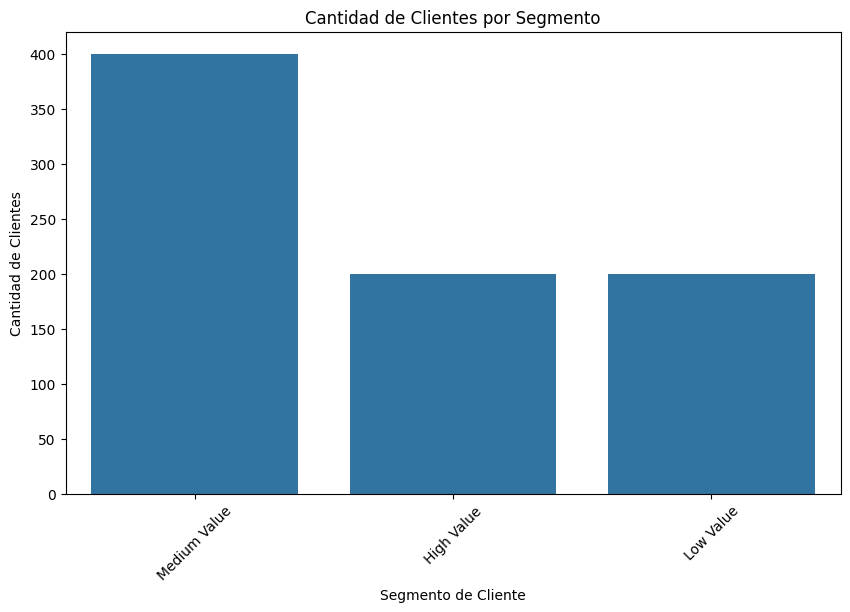

In [11]:
# visualizacion cantidad de clientes por segmento
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x="customer_segment", order=df["customer_segment"].value_counts().index)
plt.title("Cantidad de Clientes por Segmento")  
plt.xlabel("Segmento de Cliente")
plt.ylabel("Cantidad de Clientes")  
plt.xticks(rotation=45)
plt.show()



In [12]:
segment_channel = pd.crosstab(
    df["customer_segment"],
    df["channel"],
    normalize="index"
) * 100

segment_channel

channel,email marketing,paid advertising,referral,social media
customer_segment,,,,
High Value,24.0,28.5,23.50,24.00
Low Value,22.0,25.5,26.50,26.00
Medium Value,30.5,21.5,26.75,21.25


In [13]:
# valor economico por segmento y canal
df_segmented.groupby(
    ["customer_segment", "channel"]
)["net_value"].mean()

customer_segment  channel         
High Value        email marketing     4446.087333
                  paid advertising    4362.462281
                  referral            4361.339574
                  social media        4315.891500
Low Value         email marketing     1082.572182
                  paid advertising    1118.863725
                  referral            1140.585660
                  social media        1071.530923
Medium Value      email marketing     2807.688426
                  paid advertising    2753.096512
                  referral            2826.128598
                  social media        2682.571647
Name: net_value, dtype: float64

In [14]:
df_segmented.groupby(["channel", "customer_segment"])["customer_segment"].count()

channel           customer_segment
email marketing   High Value           48
                  Low Value            44
                  Medium Value        122
paid advertising  High Value           57
                  Low Value            51
                  Medium Value         86
referral          High Value           47
                  Low Value            53
                  Medium Value        107
social media      High Value           48
                  Low Value            52
                  Medium Value         85
Name: customer_segment, dtype: int64

In [15]:

df_segmented.groupby(["channel", "customer_segment"])["cost"].mean()

channel           customer_segment
email marketing   High Value           5.246263
                  Low Value            5.246263
                  Medium Value         5.246263
paid advertising  High Value          30.450327
                  Low Value           30.450327
                  Medium Value        30.450327
referral          High Value           8.320327
                  Low Value            8.320327
                  Medium Value         8.320327
social media      High Value           9.546326
                  Low Value            9.546326
                  Medium Value         9.546326
Name: cost, dtype: float64

### Análisis de oportunidades comerciales por segmento

El análisis evidencia que las diferencias entre los clientes Low Value, Medium Value y High Value no están asociadas directamente al costo de adquisición, ya que este permanece constante para los clientes provenientes de un mismo canal.

Sin embargo, se observan diferencias significativas en el Net Value promedio entre los segmentos. Esto indica que clientes adquiridos a través del mismo canal y con un costo de adquisición similar pueden generar niveles de valor económico completamente diferentes para la empresa.

Por esta razón, la principal oportunidad no consiste únicamente en optimizar o cambiar los canales de adquisición, sino en profundizar en el análisis de los clientes Low Value para identificar oportunidades de crecimiento. Mediante estrategias comerciales, ofertas personalizadas, campañas de retención, recomendaciones de productos o acciones orientadas a incrementar la conversión y el revenue, algunos clientes Low Value podrían aumentar su valor económico y evolucionar hacia segmentos Medium Value o High Value.

De esta manera, la segmentación permite pasar de un análisis descriptivo de los clientes a la identificación de oportunidades comerciales, enfocando los esfuerzos de la empresa en aquellos clientes que presentan mayor potencial de generación de valor.




In [20]:
df_segmented.head()

,customer_id,channel,cost,conversion_rate,revenue,net_value,customer_segment
0,1,referral,8.320327,0.123145,4199,4190.680,High Value
1,2,paid advertising,30.450327,0.016341,3410,3379.550,Medium Value
2,3,email marketing,5.246263,0.043822,3164,3158.754,Medium Value
3,4,social media,9.546326,0.167592,1520,1510.454,Low Value
4,5,referral,8.320327,0.123145,2419,2410.680,Medium Value


In [25]:
df_segmented.to_csv(
    "../data/customer_segmented.csv",
    index=False
)

In [26]:
import os

print(os.path.exists("../data/customer_segmented.csv"))

True
